In [8]:
import sys

sys.path.append('..')

from software import get_eye_geometry
from software import load_grayscale_image

from software.pupil_detection import detect_pupil 
from software.visualization import visualize_eye_geometry

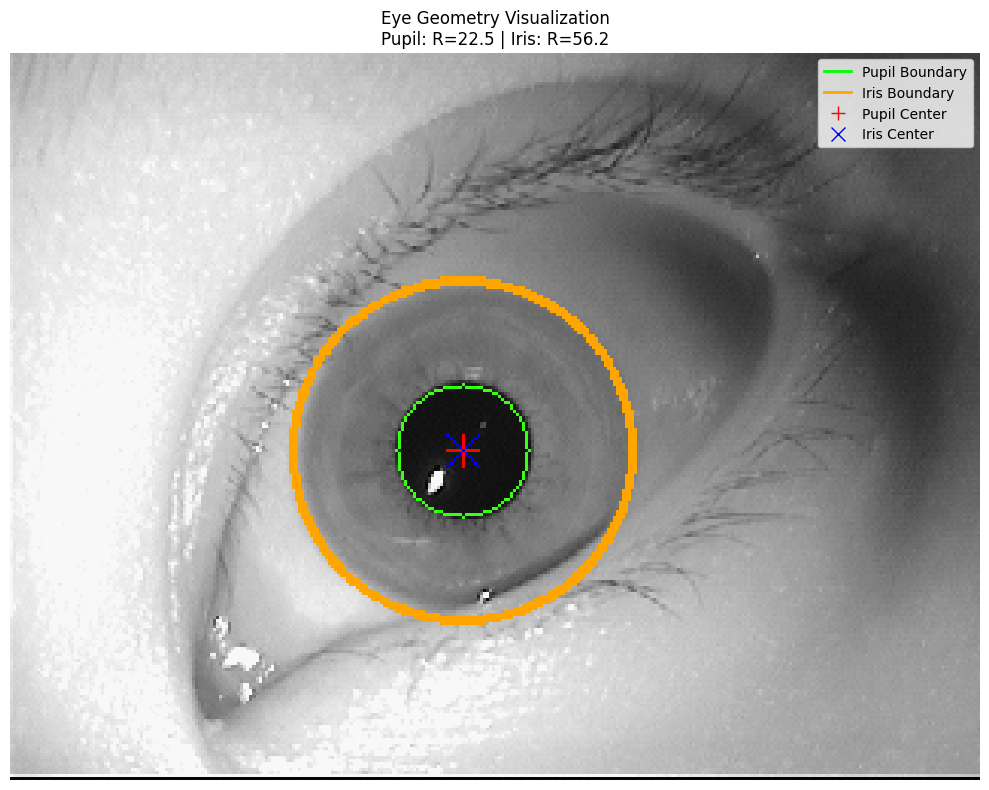

In [9]:
img_orig = load_grayscale_image('../data/MMU-Iris-Database/30/left/philipl2.bmp')
p_final, i_final = get_eye_geometry(img_orig, max_iters=100, scale_factor=0.5, contrast_step=2)


pupil = detect_pupil(img_orig)
visualize_eye_geometry(img_orig, *pupil, *i_final)

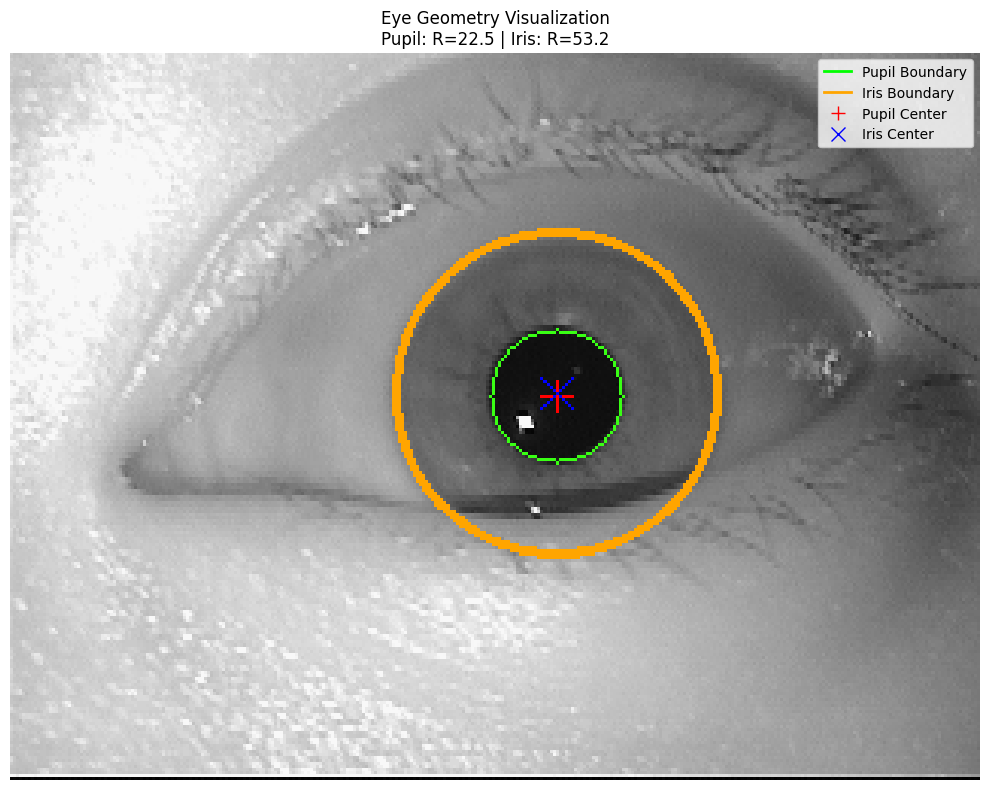

In [10]:
img_orig = load_grayscale_image('../data/MMU-Iris-Database/30/left/philipl1.bmp')
p_final, i_final = get_eye_geometry(img_orig, max_iters=100, scale_factor=0.5, contrast_step=1.5)


pupil = detect_pupil(img_orig)
visualize_eye_geometry(img_orig, *pupil, *i_final)

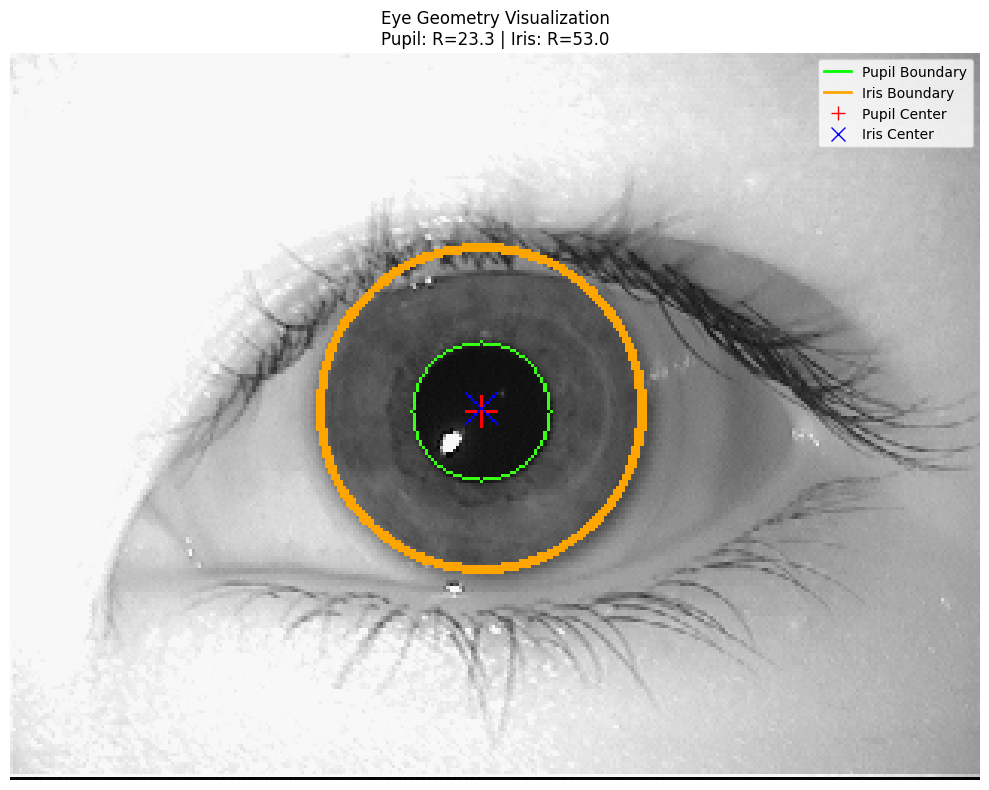

In [11]:
img_orig = load_grayscale_image('../data/MMU-Iris-Database/1/left/aeval1.bmp')
p_final, i_final = get_eye_geometry(img_orig, max_iters=100, scale_factor=0.5, contrast_step=1.5)


pupil = detect_pupil(img_orig)
visualize_eye_geometry(img_orig, *pupil, *i_final)

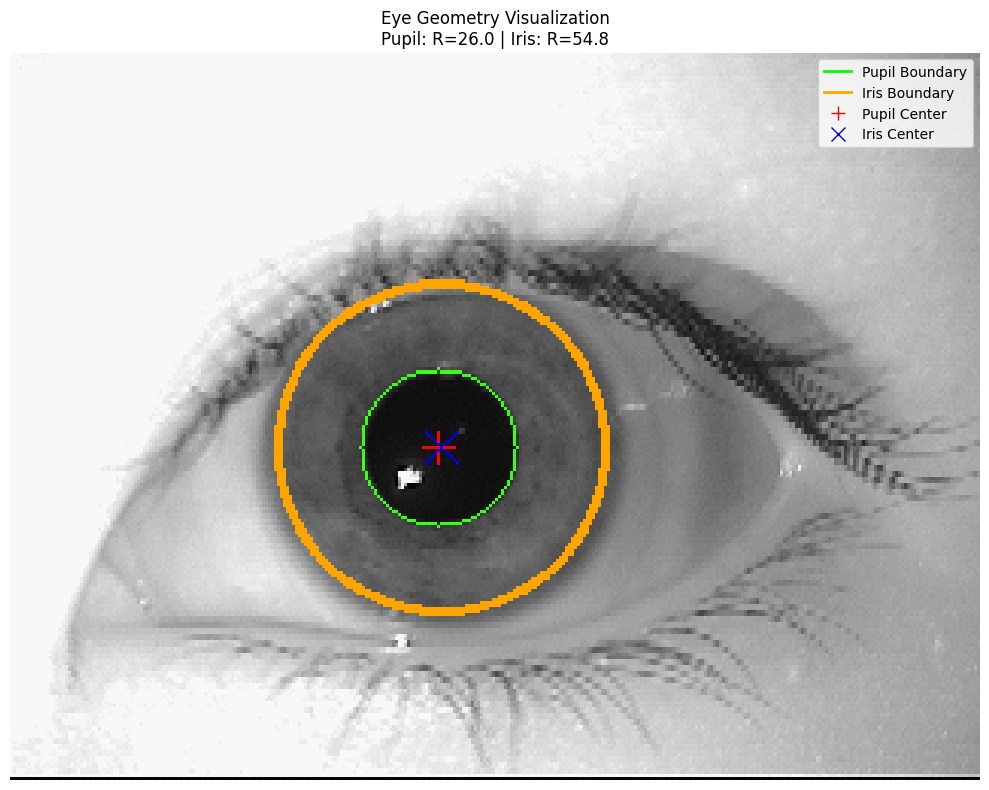

In [12]:
img_orig = load_grayscale_image('../data/MMU-Iris-Database/1/left/aeval4.bmp')
p_final, i_final = get_eye_geometry(img_orig, max_iters=5, scale_factor=0.95, contrast_step=2, show_plots=False)


pupil = detect_pupil(img_orig)
visualize_eye_geometry(img_orig, *pupil, *i_final)

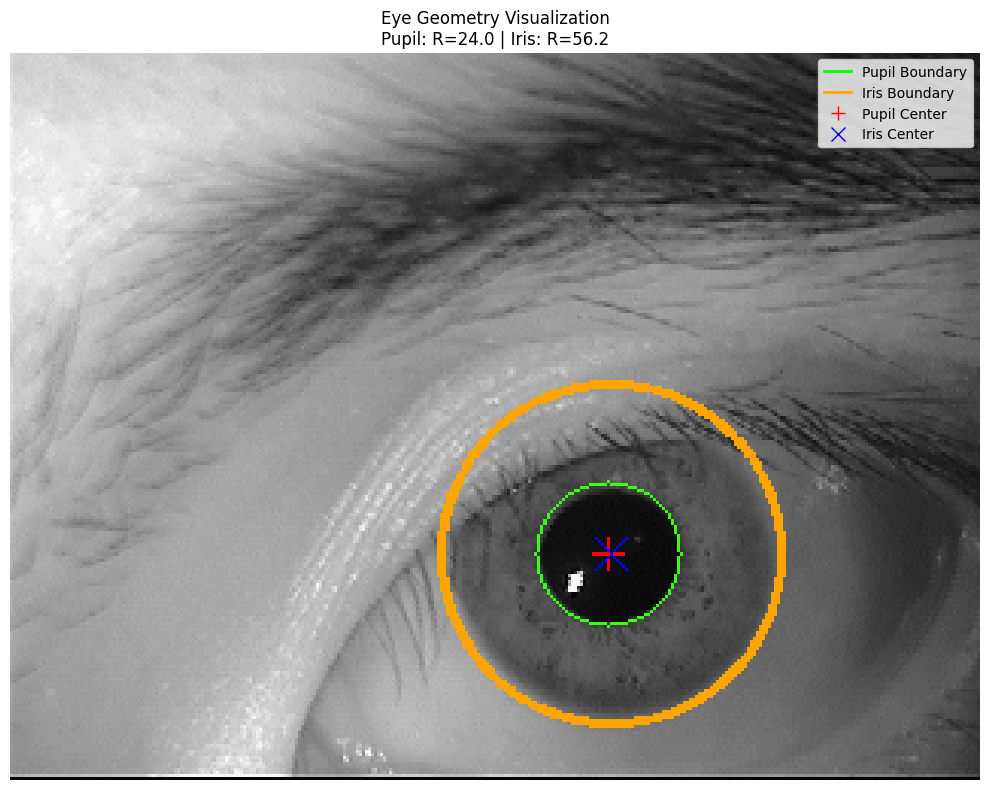

In [13]:
img_orig = load_grayscale_image('../data/MMU-Iris-Database/40/left/tonghll1.bmp')
p_final, i_final = get_eye_geometry(img_orig, max_iters=5, scale_factor=0.5, contrast_step=2, show_plots=False)


pupil = detect_pupil(img_orig)
visualize_eye_geometry(img_orig, *pupil, *i_final)

  [Info] Jasność 182.6 > 170. Przyciemniam (beta=-42)
--- Start skalowania (Rozmiar: (240, 320)) ---
  [Backup] Próba na surowym...
  [Iteracja 1] Skala: 1.000, Średnia jasność: 215.6


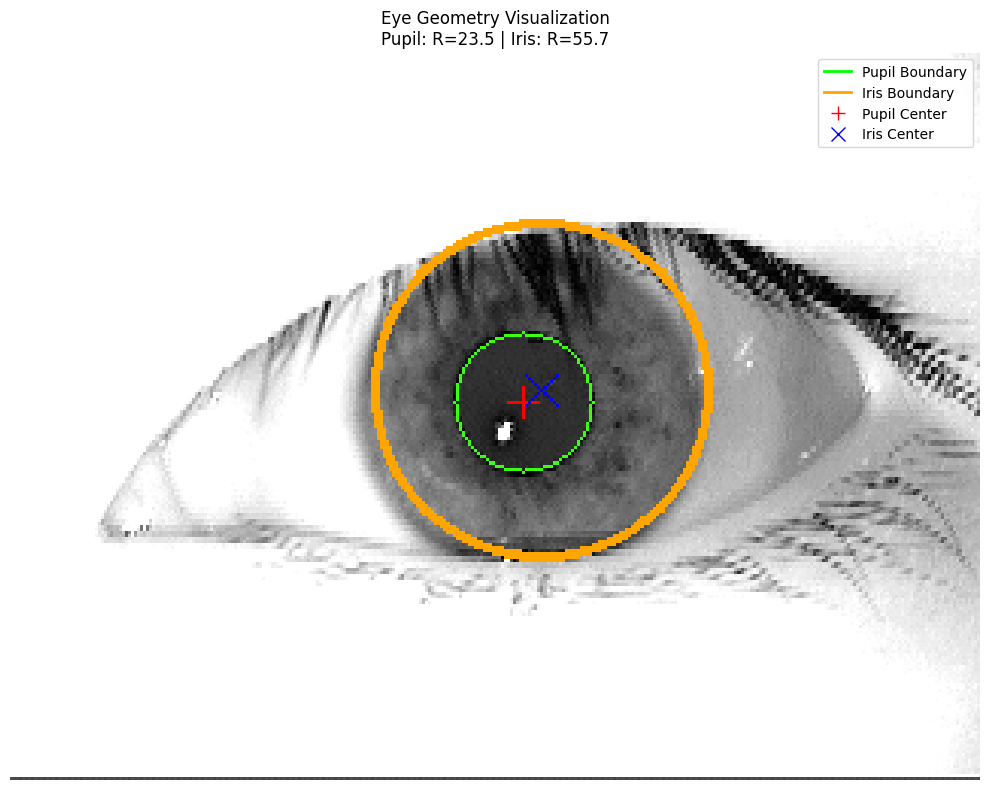

  [Iteracja 2] Brak źrenicy.


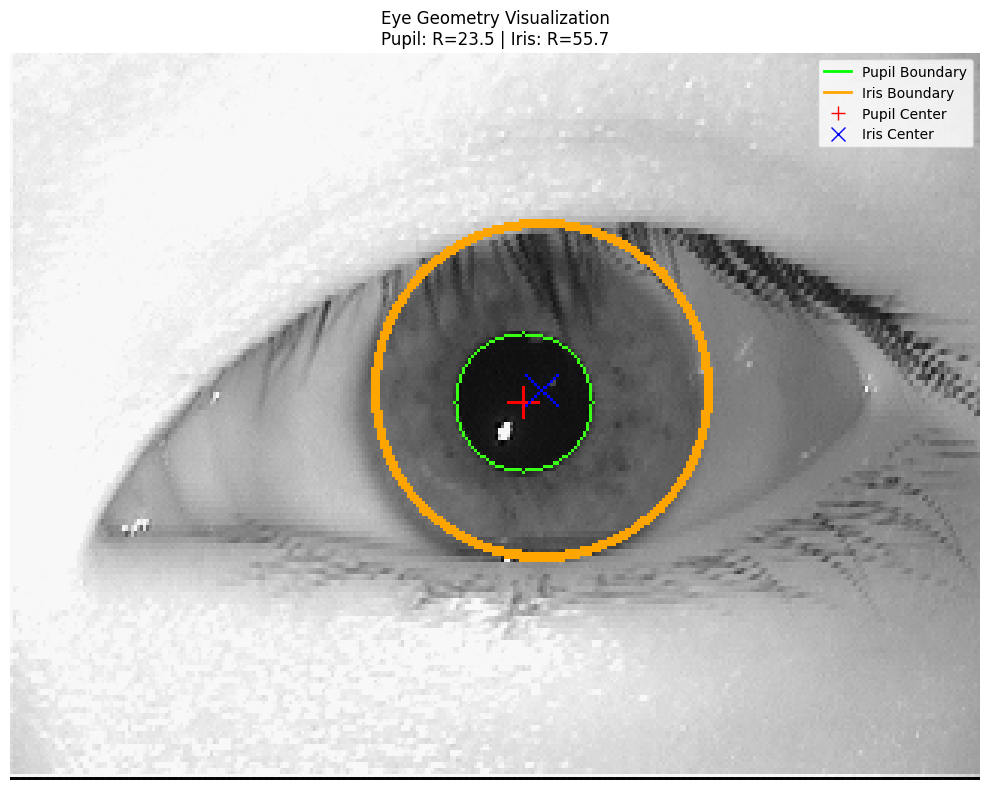

In [14]:
img_orig = load_grayscale_image('../data/MMU-Iris-Database/14/left/liujwl1.bmp')
p_final, i_final = get_eye_geometry(img_orig, max_iters=3, scale_factor=0.7, contrast_step=2, show_plots=True)


pupil = detect_pupil(img_orig)
visualize_eye_geometry(img_orig, *pupil, *i_final)

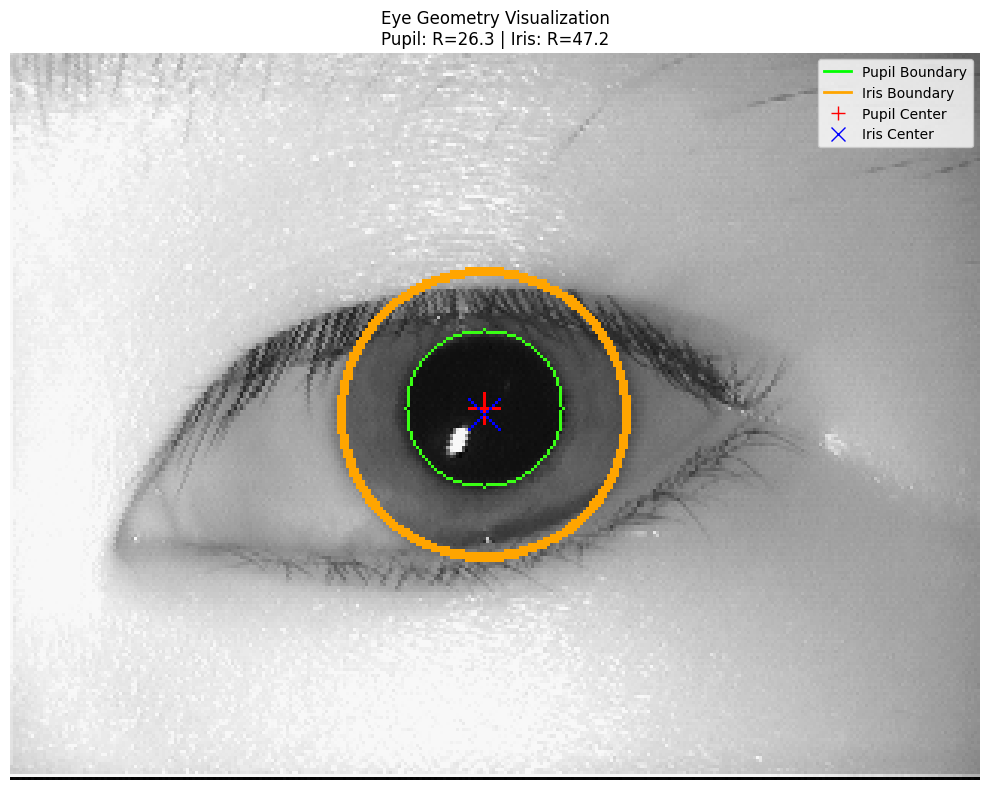

In [15]:
img_orig = load_grayscale_image('../data/MMU-Iris-Database/16/left/lowyfl1.bmp')
p_final, i_final = get_eye_geometry(img_orig, max_iters=3, scale_factor=0.7, contrast_step=2, show_plots=False)


pupil = detect_pupil(img_orig)
visualize_eye_geometry(img_orig, *pupil, *i_final)

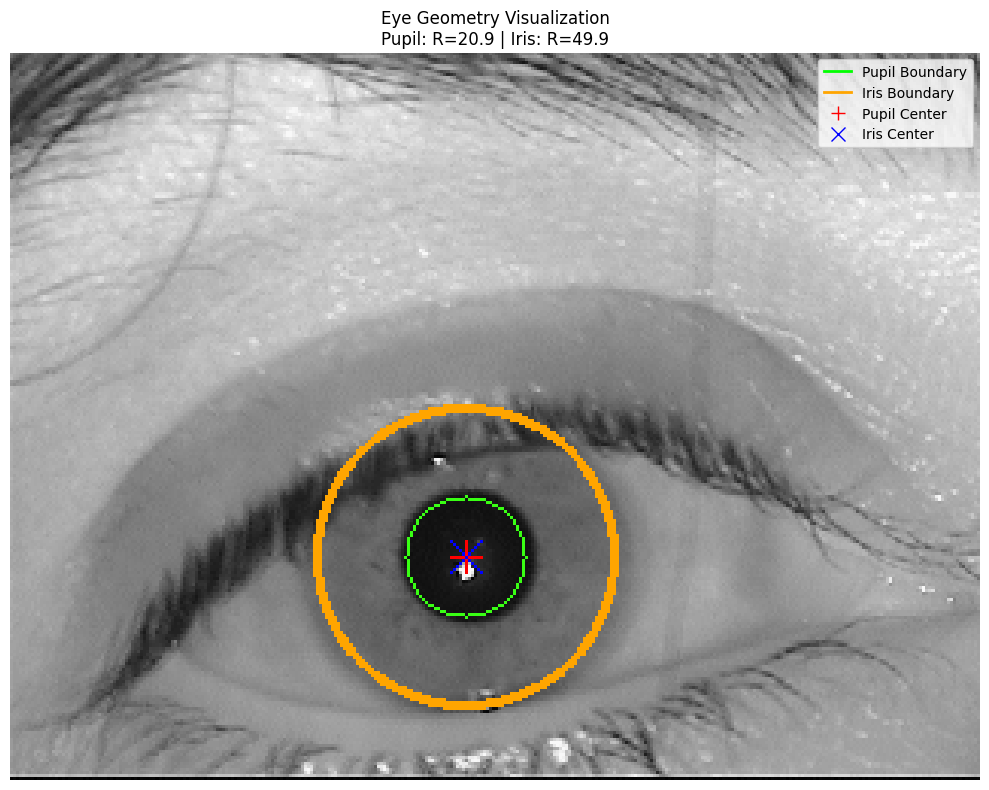

In [16]:
img_orig = load_grayscale_image('../data/MMU-Iris-Database/13/left/lec_1.bmp')
p_final, i_final = get_eye_geometry(img_orig, max_iters=3, scale_factor=0.7, contrast_step=2, show_plots=False)


pupil = detect_pupil(img_orig)
visualize_eye_geometry(img_orig, *p_final, *i_final)

In [17]:
import numpy as np
import cv2

class EyeMetric:
    def __init__(self, image):
        self.img = image.astype(np.float32)
        self.h, self.w = image.shape

        # Precompute gradienty (Sobel)
        self.grad_x = cv2.Sobel(self.img, cv2.CV_32F, 1, 0, ksize=3)
        self.grad_y = cv2.Sobel(self.img, cv2.CV_32F, 0, 1, ksize=3)
        self.grad_mag = np.sqrt(self.grad_x**2 + self.grad_y**2) + 1e-6

    # -------------------------
    # INTERPOLACJA (ważne!)
    # -------------------------
    def _bilinear(self, x, y):
        x0, y0 = int(x), int(y)
        x1, y1 = min(x0 + 1, self.w - 1), min(y0 + 1, self.h - 1)

        dx, dy = x - x0, y - y0

        val = (
            self.img[y0, x0] * (1 - dx) * (1 - dy) +
            self.img[y0, x1] * dx * (1 - dy) +
            self.img[y1, x0] * (1 - dx) * dy +
            self.img[y1, x1] * dx * dy
        )
        return val

    # -------------------------
    # MASKI
    # -------------------------
    def _circle_mask(self, x, y, r):
        Y, X = np.ogrid[:self.h, :self.w]
        return (X - x)**2 + (Y - y)**2 <= r**2

    def _annulus_mask(self, x, y, r1, r2):
        Y, X = np.ogrid[:self.h, :self.w]
        dist2 = (X - x)**2 + (Y - y)**2
        return (r1**2 <= dist2) & (dist2 <= r2**2)

    # -------------------------
    # 1. DAUGMAN-LIKE SCORE
    # -------------------------
    def daugman_score(self, x, y, r, samples=120):
        angles = np.linspace(0, 2*np.pi, samples)

        vals = []
        grads = []

        for a in angles:
            px = x + r * np.cos(a)
            py = y + r * np.sin(a)

            if 1 <= px < self.w-1 and 1 <= py < self.h-1:
                val = self._bilinear(px, py)
                gx = self.grad_x[int(py), int(px)]
                gy = self.grad_y[int(py), int(px)]

                # kierunek radialny
                rx, ry = np.cos(a), np.sin(a)
                radial_grad = gx * rx + gy * ry

                vals.append(val)
                grads.append(radial_grad)

        if len(grads) < 10:
            return 0

        grads = np.array(grads)

        # normalizacja energii (jak w Daugmanie)
        score = np.mean(grads) / (np.std(grads) + 1e-6)

        return max(0, score)

    # -------------------------
    # 2. ROBUST CONTRAST
    # -------------------------
    def robust_contrast(self, pupil_mask, iris_mask):
        p = self.img[pupil_mask]
        i = self.img[iris_mask]

        if len(p) < 10 or len(i) < 10:
            return 0

        # median zamiast mean (odporność na odblaski)
        mp = np.median(p)
        mi = np.median(i)

        return np.clip((mi - mp) / (mi + 1e-6), 0, 1)

    # -------------------------
    # 3. EDGE ALIGNMENT
    # -------------------------
    def edge_alignment(self, x, y, r, samples=120):
        angles = np.linspace(0, 2*np.pi, samples)

        scores = []

        for a in angles:
            px = x + r * np.cos(a)
            py = y + r * np.sin(a)

            if 1 <= px < self.w-1 and 1 <= py < self.h-1:
                gx = self.grad_x[int(py), int(px)]
                gy = self.grad_y[int(py), int(px)]

                grad_norm = np.sqrt(gx**2 + gy**2) + 1e-6

                gx /= grad_norm
                gy /= grad_norm

                # radial vector
                rx, ry = np.cos(a), np.sin(a)

                # cos similarity
                alignment = abs(gx * rx + gy * ry)
                scores.append(alignment)

        if len(scores) == 0:
            return 0

        return np.mean(scores)

    # -------------------------
    # 4. GEOMETRY (IoU-like)
    # -------------------------
    def geometry_score(self, xp, yp, rp, xi, yi, ri):
        dist = np.sqrt((xp-xi)**2 + (yp-yi)**2)

        if dist + rp > ri:
            return 0

        return np.exp(-dist / (ri - rp + 1e-6))

    # -------------------------
    # 5. LEAKAGE (ulepszone)
    # -------------------------
    def leakage_score(self, xp, yp, rp):
        ring = self._annulus_mask(xp, yp, rp, rp+4)
        vals = self.img[ring]

        if len(vals) == 0:
            return 1

        threshold = np.percentile(self.img, 20)
        leakage = np.mean(vals < threshold)

        return 1 - leakage

    # -------------------------
    # 6. RADIAL CONSISTENCY
    # -------------------------
    def radial_consistency(self, x, y, r_inner, r_outer, samples=50):
        radii = np.linspace(r_inner, r_outer, 10)
        angles = np.linspace(0, 2*np.pi, samples)

        profiles = []

        for r in radii:
            vals = []
            for a in angles:
                px = x + r*np.cos(a)
                py = y + r*np.sin(a)

                if 0 <= px < self.w and 0 <= py < self.h:
                    vals.append(self._bilinear(px, py))

            if len(vals) > 0:
                profiles.append(np.std(vals))

        if len(profiles) == 0:
            return 0

        return 1 / (np.mean(profiles) + 1e-6)

    # -------------------------
    # FINAL SCORE
    # -------------------------
    def evaluate(self, p_params, i_params):
        xp, yp, rp = p_params
        xi, yi, ri = i_params

        pupil_mask = self._circle_mask(xp, yp, rp)
        iris_mask = self._annulus_mask(xi, yi, rp, ri)

        g_p = self.daugman_score(xp, yp, rp)
        g_i = self.daugman_score(xi, yi, ri)

        align_p = self.edge_alignment(xp, yp, rp)
        align_i = self.edge_alignment(xi, yi, ri)

        contrast = self.robust_contrast(pupil_mask, iris_mask)
        geo = self.geometry_score(xp, yp, rp, xi, yi, ri)
        leak = self.leakage_score(xp, yp, rp)
        radial = self.radial_consistency(xi, yi, rp, ri)

        # NORMALIZACJA
        g_p = np.tanh(g_p)
        g_i = np.tanh(g_i)

        final = (
            0.25 * g_p +
            0.15 * g_i +
            0.15 * align_p +
            0.10 * align_i +
            0.15 * contrast +
            0.10 * geo +
            0.05 * leak +
            0.05 * radial
        )

        return float(np.clip(final, 0, 1))

In [18]:
 # (x, y, r)

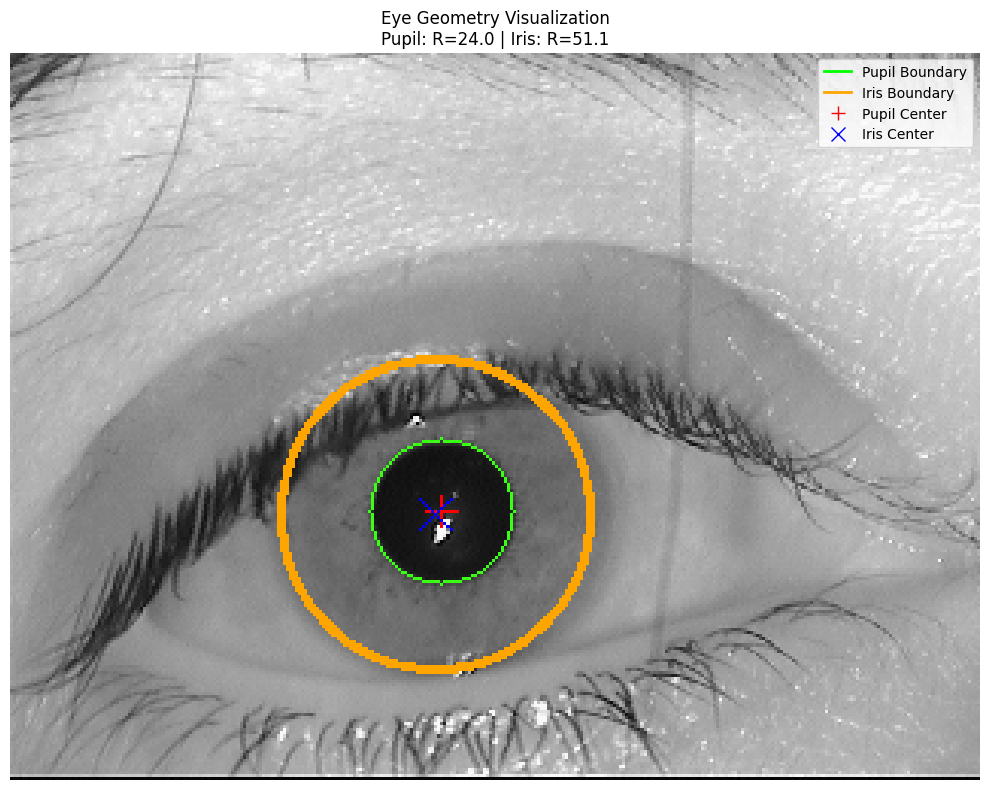

0.7273706457794191

In [19]:
img_orig = load_grayscale_image('../data/MMU-Iris-Database/13/left/lecl2.bmp')
p_final, i_final = get_eye_geometry(img_orig, max_iters=3, scale_factor=0.5, contrast_step=1.5, show_plots=False, )


pupil = detect_pupil(img_orig)
visualize_eye_geometry(img_orig, *p_final, *i_final)

evaluator = EyeMetric(img_orig)
evaluator.evaluate(pupil, i_final)

In [20]:
import itertools

from software import Evaluator

def geometry_distance(p1, i1, p2, i2):
    xp1, yp1, rp1 = p1
    xi1, yi1, ri1 = i1

    xp2, yp2, rp2 = p2
    xi2, yi2, ri2 = i2

    return np.sqrt(
        (xp1 - xp2)**2 +
        (yp1 - yp2)**2 +
        (rp1 - rp2)**2 +
        (xi1 - xi2)**2 +
        (yi1 - yi2)**2 +
        (ri1 - ri2)**2
    )


def grid_search_eye(
    img,
    param_grid,
    top_k=5,
    verbose=False,
    eps=1.0  # tolerancja w pikselach
):
    keys = list(param_grid.keys())
    values = list(param_grid.values())

    combinations = list(itertools.product(*values))

    evaluator = Evaluator(img)
    results = []

    # 🔥 do deduplikacji
    seen = set()

    def quantize(val):
        return int(round(val / eps))

    def geometry_key(pupil, iris):
        xp, yp, rp = pupil
        xi, yi, ri = iris

        return (
            quantize(xp), quantize(yp), quantize(rp),
            quantize(xi), quantize(yi), quantize(ri),
        )

    for idx, combo in enumerate(combinations):
        base_params = dict(zip(keys, combo))

        # --- budowa parametrów ---
        n_start_adv = base_params.get("n_start_adv", 15)
        gap_adv = base_params.get("gap_adv", 10)

        n_start_ref = base_params.get("n_start_ref", 10)
        gap_ref = base_params.get("gap_ref", 10)

        if gap_adv < 5 or gap_ref < 5:
            continue

        n_end_adv = n_start_adv + gap_adv
        n_end_ref = n_start_ref + gap_ref

        params = {
            "max_iters": base_params.get("max_iters", 3),
            "scale_factor": base_params.get("scale_factor", 0.95),
            "contrast_step": base_params.get("contrast_step", 1.01),
            "n_start_adv": n_start_adv,
            "n_end_adv": n_end_adv,
            "n_start_ref": n_start_ref,
            "n_end_ref": n_end_ref,
        }

        try:
            pupil, iris = get_eye_geometry(
                img,
                max_iters=params["max_iters"],
                scale_factor=params["scale_factor"],
                contrast_step=params["contrast_step"],
                show_plots=False,
                n_start_adv=params["n_start_adv"],
                n_end_adv=params["n_end_adv"],
                n_start_ref=params["n_start_ref"],
                n_end_ref=params["n_end_ref"],
            )

            # szybki reject
            if pupil[2] < 5 or iris[2] <= pupil[2]:
                continue

            # 🔥 deduplikacja
            key = geometry_key(pupil, iris)
            if key in seen:
                continue
            seen.add(key)

            score = evaluator.evaluate(pupil, iris)

            results.append({
                "score": score,
                "params": params,
                "pupil": pupil,
                "iris": iris
            })

            if verbose:
                print(f"[{idx+1}/{len(combinations)}] score={score:.4f}")

        except Exception as e:
            if verbose:
                print(f"[ERROR] {params} -> {e}")
            continue

    results = sorted(results, key=lambda x: x["score"], reverse=True)

    return results[:top_k]

In [21]:
def average_top_results(results, trim_ratio=0.2, use_weights=True):
    """
    results: lista wyników z grid_search_eye
    trim_ratio: ile % najgorszych odciąć (robustness)
    use_weights: czy używać wag (score)
    """

    if len(results) == 0:
        return None, None

    # -------------------------
    # 1. SORTOWANIE
    # -------------------------
    results = sorted(results, key=lambda x: x["score"], reverse=True)

    # -------------------------
    # 2. TRIMMING (usuwamy outliery)
    # -------------------------
    n = len(results)
    keep_n = int(n * (1 - trim_ratio))
    results = results[:max(1, keep_n)]

    # -------------------------
    # 3. WAGI
    # -------------------------
    if use_weights:
        scores = np.array([r["score"] for r in results])
        weights = scores / (np.sum(scores) + 1e-6)
    else:
        weights = np.ones(len(results)) / len(results)

    # -------------------------
    # 4. EKSTRAKCJA PARAMETRÓW
    # -------------------------
    pupils = np.array([r["pupil"] for r in results])  # (N, 3)
    irises = np.array([r["iris"] for r in results])   # (N, 3)

    # -------------------------
    # 5. ŚREDNIA WAŻONA
    # -------------------------
    p_avg = np.sum(pupils * weights[:, None], axis=0)
    i_avg = np.sum(irises * weights[:, None], axis=0)

    return tuple(p_avg), tuple(i_avg)

In [22]:
param_grid = {
    "max_iters": [10],
    "scale_factor": [0.5, 0.7, 0.9],
    "contrast_step": [1.01, 1.05, 1.1, 1.2, 1.5, 2, 3, 5],

    "n_start_adv": [10, 20],
    "gap_adv": [5, 10, 15],

    "n_start_ref": [8, 12],
    "gap_ref": [5, 10, 15],
}

In [35]:
img = load_grayscale_image('../data/MMU-Iris-Database/30/right/philipr4.bmp')

top_results = grid_search_eye(
    img,
    param_grid,
    top_k=5,
    verbose=False
)

In [36]:
avg = average_top_results(top_results)

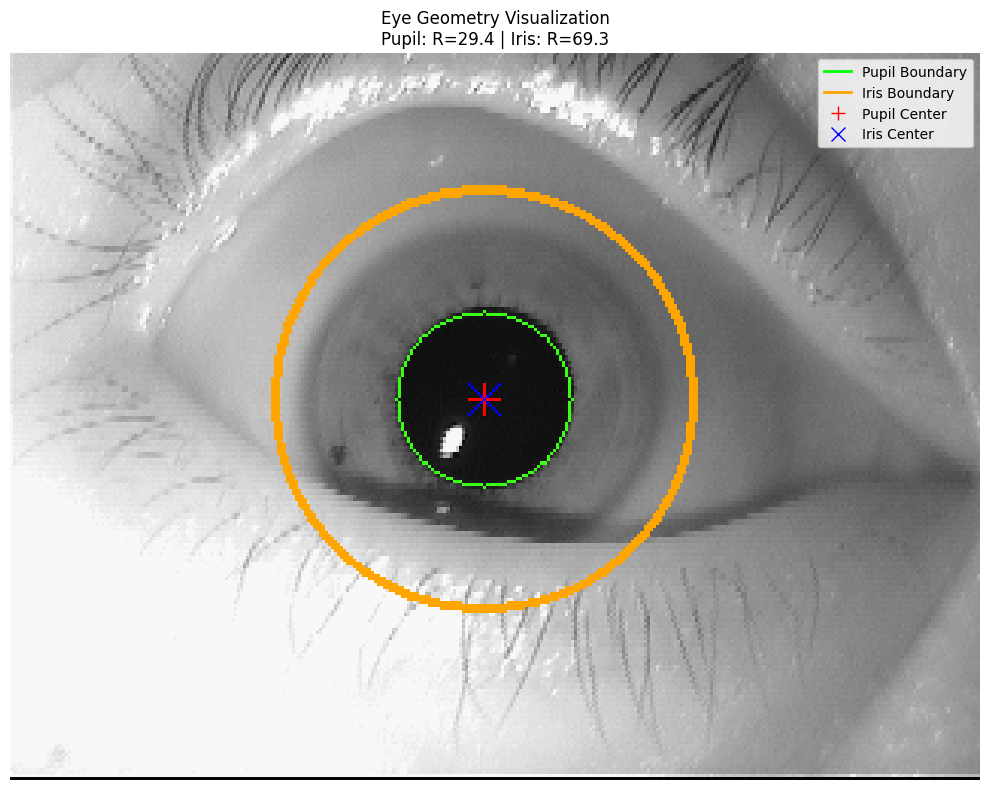

In [37]:
visualize_eye_geometry(img, *avg[0], *avg[1])


===== TOP 1 | score=0.8379 =====


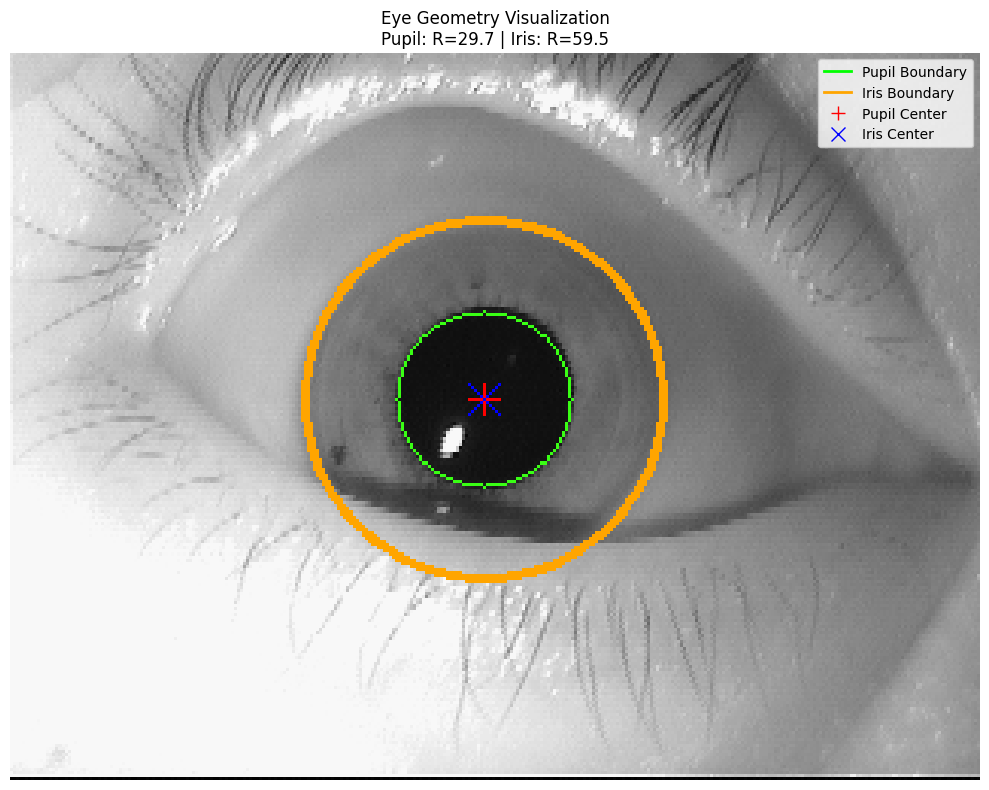


===== TOP 2 | score=0.7225 =====


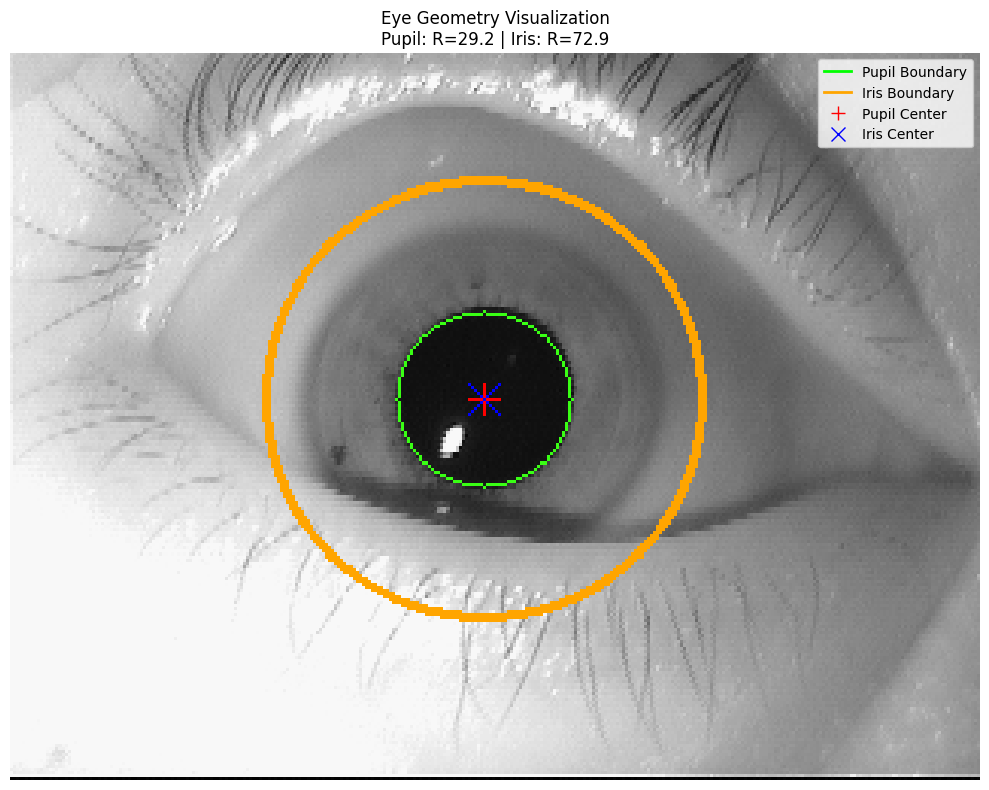


===== TOP 3 | score=0.7109 =====


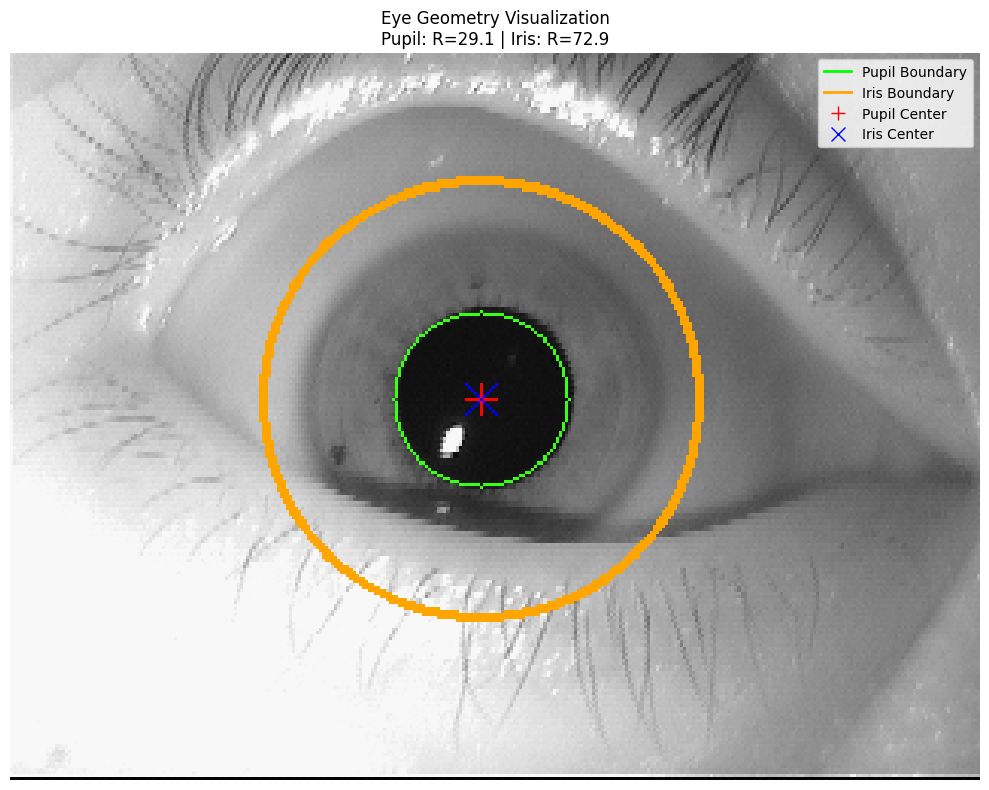


===== TOP 4 | score=0.7095 =====


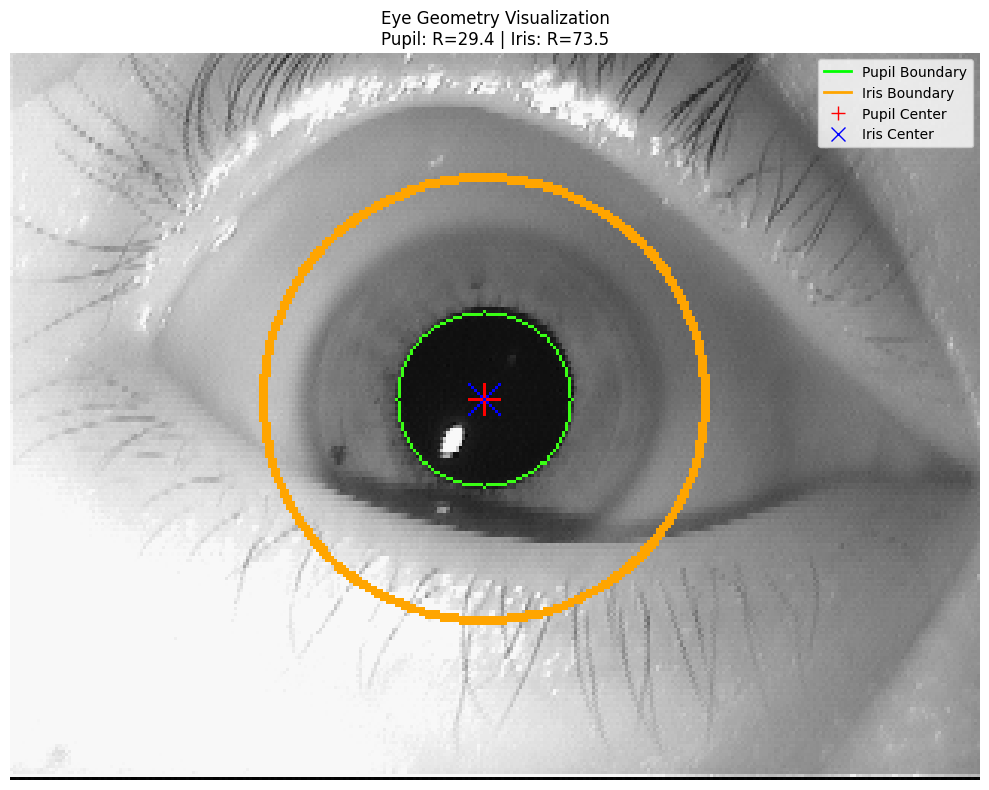


===== TOP 5 | score=0.7074 =====


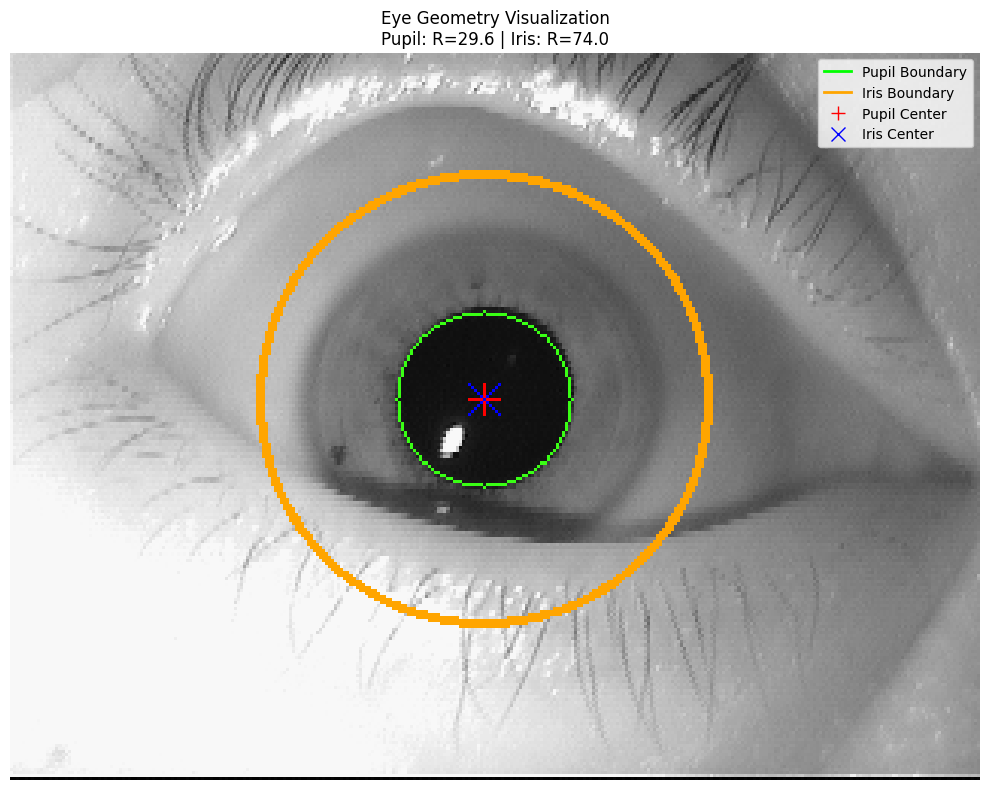

In [38]:
for i, res in enumerate(top_results):
    print(f"\n===== TOP {i+1} | score={res['score']:.4f} =====")

    p_final = res["pupil"]
    i_final = res["iris"]

    visualize_eye_geometry(
        img,   # img_orig
        *p_final,
        *i_final
    )

# Final solution

In [1]:
import sys

sys.path.append('..')

In [2]:
from software import find_optimal_eye_geometry
from software import load_grayscale_image
from software.visualization import visualize_eye_geometry

In [3]:
param_grid = {
    "max_iters": [10],
    "scale_factor": [0.5, 0.6, 0.7, 0.8, 0.9],
    "contrast_step": [1.01, 1.05, 1.1, 1.2, 1.5, 2, 3, 5],

    "n_start_adv": [10, 20],
    "gap_adv": [5, 10, 15],

    "n_start_ref": [8, 12],
    "gap_ref": [5, 10, 15],
}

In [4]:
image = load_grayscale_image('../data/MMU-Iris-Database/29/left/pcll1.bmp')

In [5]:
final_pupil, final_iris = find_optimal_eye_geometry(image, param_grid, top_k=3)

Optimizing Eye Geometry: 100%|████████████████████████████████████████████████████| 1440/1440 [01:51<00:00, 12.86cfg/s]


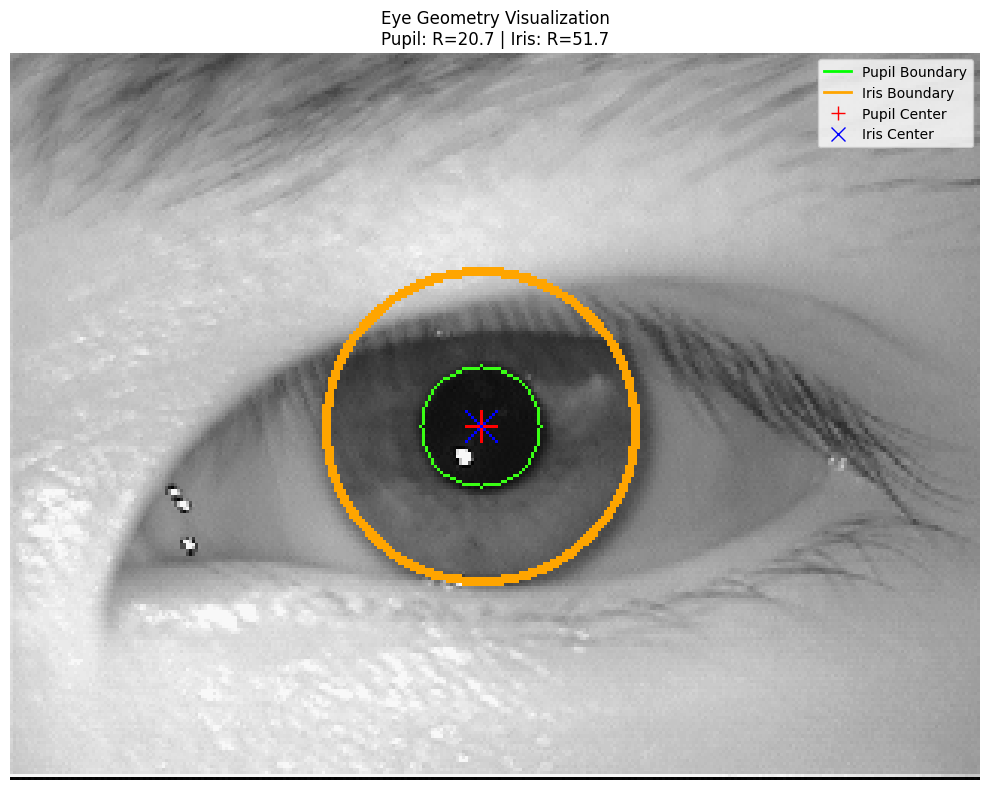

In [6]:
visualize_eye_geometry(image, *final_pupil, *final_iris)

Optimizing Eye Geometry: 100%|████████████████████████████████████████████████████| 1440/1440 [01:46<00:00, 13.52cfg/s]


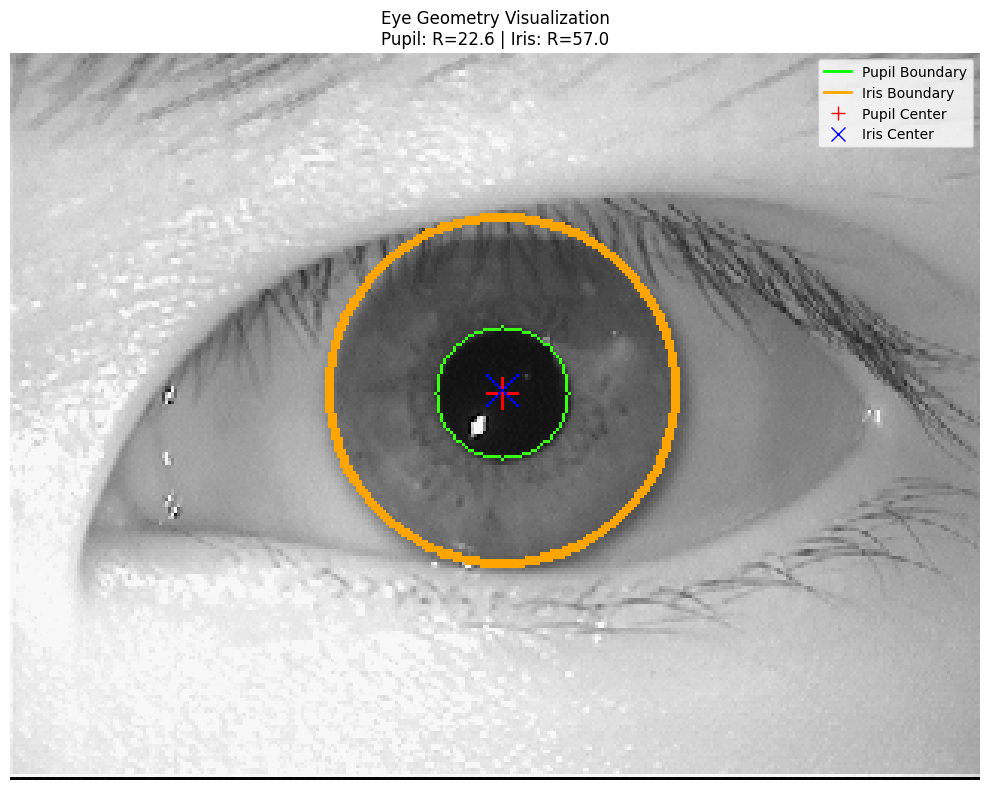

In [39]:
image = load_grayscale_image('../data/MMU-Iris-Database/29/left/pcll2.bmp')
final_pupil, final_iris = find_optimal_eye_geometry(image, param_grid, top_k=1)
visualize_eye_geometry(image, *final_pupil, *final_iris)

Optimizing Eye Geometry: 100%|████████████████████████████████████████████████████| 1440/1440 [01:53<00:00, 12.65cfg/s]


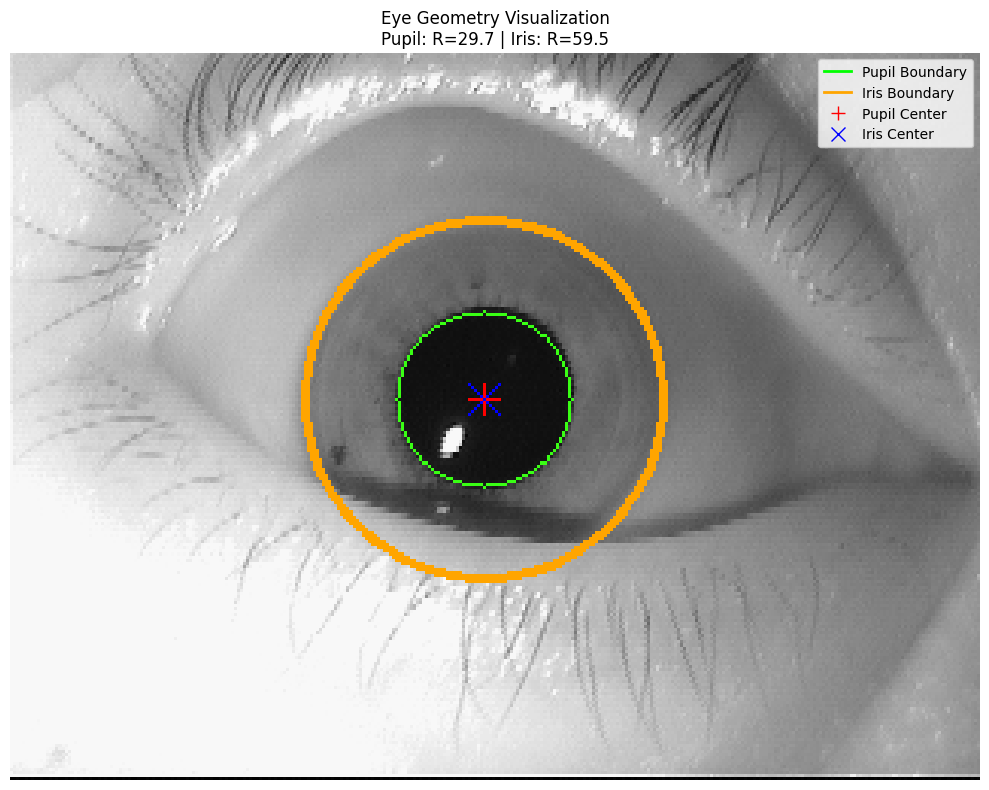

In [40]:
image = load_grayscale_image('../data/MMU-Iris-Database/30/right/philipr4.bmp')
final_pupil, final_iris = find_optimal_eye_geometry(image, param_grid, top_k=1)
visualize_eye_geometry(image, *final_pupil, *final_iris)

Optimizing Eye Geometry: 100%|████████████████████████████████████████████████████| 1440/1440 [01:08<00:00, 20.94cfg/s]


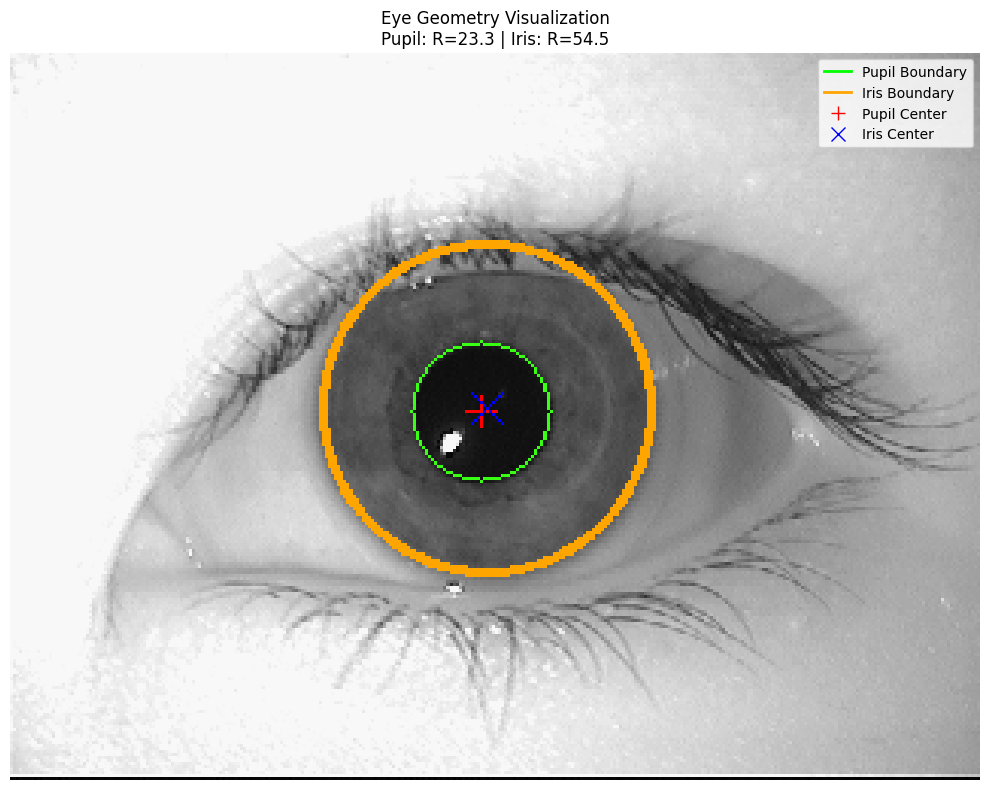

In [11]:
image = load_grayscale_image('../data/MMU-Iris-Database/1/left/aeval1.bmp')
final_pupil, final_iris = find_optimal_eye_geometry(image, param_grid, top_k=1)
visualize_eye_geometry(image, *final_pupil, *final_iris)

In [12]:
from software._unroll_iris import unroll_iris

In [13]:
import numpy as np

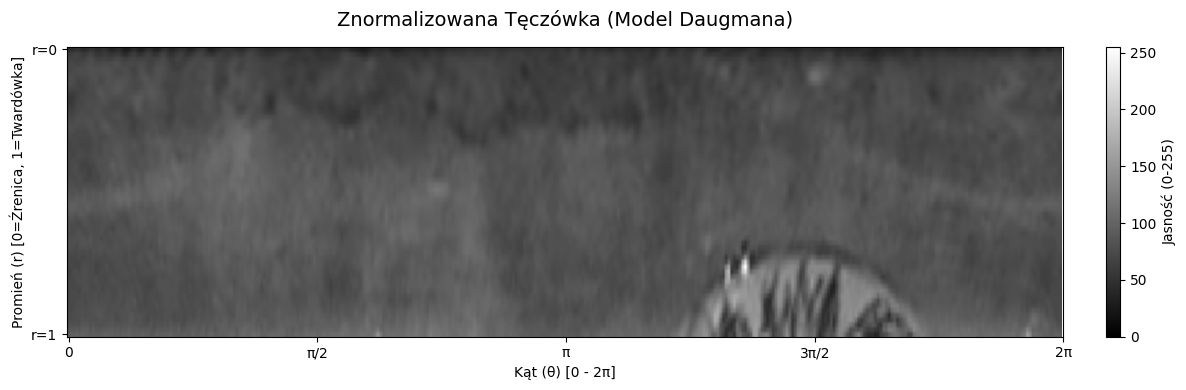

In [14]:
import matplotlib.pyplot as plt

# 1. Wygeneruj prostokąt (używając Twojej istniejącej funkcji)
normalized_iris = unroll_iris(image, final_pupil, final_iris)

# 2. Wyświetl za pomocą Matplotlib
plt.figure(figsize=(12, 4))
plt.imshow(normalized_iris, cmap='gray', vmin=0, vmax=255, aspect='auto')

# Estetyka i opis osi
plt.title("Znormalizowana Tęczówka (Model Daugmana)", fontsize=14, pad=15)
plt.xlabel("Kąt (θ) [0 - 2π]", fontsize=10)
plt.ylabel("Promień (r) [0=Źrenica, 1=Twardówka]", fontsize=10)

# Ustawienie czytelnych podziałek
plt.xticks(np.linspace(0, normalized_iris.shape[1], 5), 
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.yticks([0, normalized_iris.shape[0]-1], ['r=0', 'r=1'])

plt.colorbar(label="Jasność (0-255)", fraction=0.02, pad=0.04)
plt.tight_layout()
plt.show()